In [ ]:
#SVM+LOGISTIC REGRESSION
!pip install scikit-learn pandas -q

In [ ]:
import pandas as pd
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import SGDClassifier, LogisticRegression
from sklearn.ensemble import VotingClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score

In [ ]:
train_df = pd.read_csv("tamil_offensive_full_train (1).csv")
dev_df = pd.read_csv("tamil_offensive_full_dev.csv")
test_df = pd.read_csv("tamil_offensive_test_without_labels.csv")

In [ ]:
train_df = train_df.rename(columns={"Text": "text", "Labels": "label"})
dev_df = dev_df.rename(columns={"Text": "text", "Labels": "label"})

# ✅ 5. Clean Tamil text
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"[^A-Za-zஅ-ஹா-ௌ0-9\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

train_df['text'] = train_df['text'].apply(clean_text)
dev_df['text'] = dev_df['text'].apply(clean_text)
test_df['Text'] = test_df['Text'].apply(clean_text)

# ✅ 6. Encode labels
le = LabelEncoder()
train_df['label'] = le.fit_transform(train_df['label'])
dev_df['label'] = le.transform(dev_df['label'])

# ✅ 7. TF-IDF Vectorization
tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1, 3))
X_train = tfidf.fit_transform(train_df['text'])
X_dev = tfidf.transform(dev_df['text'])
X_test = tfidf.transform(test_df['Text'])

# ✅ 8. Define base models
svm = SGDClassifier(loss='hinge', penalty='l2', alpha=1e-5, max_iter=1000, random_state=42)
log_reg = LogisticRegression(C=1.0, solver='liblinear', max_iter=1000)

# ✅ 9. Voting ensemble
ensemble_model = VotingClassifier(
    estimators=[('svm', svm), ('logreg', log_reg)],
    voting='hard'  # Try 'soft' if both support predict_proba
)

# ✅ 10. Train the ensemble
ensemble_model.fit(X_train, train_df['label'])

# ✅ 11. Evaluate
dev_preds = ensemble_model.predict(X_dev)
accuracy = accuracy_score(dev_df['label'], dev_preds)
print("✅ Ensemble Accuracy on dev set:", round(accuracy, 4))

# ✅ 12. Predict test set
test_preds = ensemble_model.predict(X_test)
test_labels = le.inverse_transform(test_preds)

# ✅ 13. Save predictions
output_df = pd.DataFrame({"Text": test_df["Text"], "Predicted_Labels": test_labels})
output_df.to_csv("ensemble_tamil_test_predictions.csv", index=False)
print("✅ Predictions saved to: ensemble_tamil_test_predictions.csv")

✅ Ensemble Accuracy on dev set: 0.7714
✅ Predictions saved to: ensemble_tamil_test_predictions.csv


In [ ]:
# ✅ 1. LINEAR SVM,LOGISTIC REGRESSION,MULTINOMIAL NAIVE MAYES ETC
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import accuracy_score

# ✅ 2. Load and clean data
train_df = pd.read_csv("tamil_offensive_full_train (1).csv")
dev_df = pd.read_csv("tamil_offensive_full_dev.csv")
test_df = pd.read_csv("tamil_offensive_test_without_labels.csv")

train_df = train_df.rename(columns={"Text": "text", "Labels": "label"})
dev_df = dev_df.rename(columns={"Text": "text", "Labels": "label"})

# ✅ 3. Label Encoding
le = LabelEncoder()
train_df["label"] = le.fit_transform(train_df["label"])
dev_df["label"] = le.transform(dev_df["label"])

# ✅ 4. TF-IDF vectorization
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_train = vectorizer.fit_transform(train_df["text"])
X_dev = vectorizer.transform(dev_df["text"])
X_test = vectorizer.transform(test_df["Text"])

y_train = train_df["label"]
y_dev = dev_df["label"]

# ✅ 5. Define individual models
svm_model = LinearSVC()
lr_model = LogisticRegression(max_iter=1000)
nb_model = MultinomialNB()

# ✅ 6. Ensemble model with Voting
ensemble_model = VotingClassifier(
    estimators=[
        ('svm', svm_model),
        ('logreg', lr_model),
        ('nb', nb_model)
    ],
    voting='hard'  # use majority voting
)

# ✅ 7. Train
ensemble_model.fit(X_train, y_train)

# ✅ 8. Evaluate
y_pred = ensemble_model.predict(X_dev)
accuracy = accuracy_score(y_dev, y_pred)
print(f"✅ Ensemble Validation Accuracy: {accuracy:.4f}")

# ✅ 9. Predict on test data
test_preds = ensemble_model.predict(X_test)
test_labels = le.inverse_transform(test_preds)

# ✅ 10. Save predictions
output_df = pd.DataFrame({
    "Text": test_df["Text"],
    "Predicted_Label": test_labels
})

output_df.to_csv("tamil_test_predictions.csv", index=False)
print("✅ Test predictions saved to tamil_test_predictions.csv")

# ✅ 11. Download
files.download("tamil_test_predictions.csv")

✅ Ensemble Validation Accuracy: 0.7746
✅ Test predictions saved to tamil_test_predictions.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import files
files.download("tamil_test_predictions.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ✅ 1. LINEAR SVM,LOGISTIC REGRESSION,MULTINOMIAL NAIVE MAYES ETC
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import accuracy_score

# ✅ 2. Load and clean data
train_df = pd.read_csv("mal_full_offensive_train.csv")
dev_df = pd.read_csv("mal_full_offensive_dev.csv")
test_df = pd.read_csv("mal_offensive_test_without_labels.csv")

train_df = train_df.rename(columns={"Text": "text", "Labels": "label"})
dev_df = dev_df.rename(columns={"Text": "text", "Labels": "label"})

# ✅ 3. Label Encoding
le = LabelEncoder()
train_df["label"] = le.fit_transform(train_df["label"])
dev_df["label"] = le.transform(dev_df["label"])

# ✅ 4. TF-IDF vectorization
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_train = vectorizer.fit_transform(train_df["text"])
X_dev = vectorizer.transform(dev_df["text"])
X_test = vectorizer.transform(test_df["Text"])

y_train = train_df["label"]
y_dev = dev_df["label"]

# ✅ 5. Define individual models
svm_model = LinearSVC()
lr_model = LogisticRegression(max_iter=1000)
nb_model = MultinomialNB()

# ✅ 6. Ensemble model with Voting
ensemble_model = VotingClassifier(
    estimators=[
        ('svm', svm_model),
        ('logreg', lr_model),
        ('nb', nb_model)
    ],
    voting='hard'  # use majority voting
)

# ✅ 7. Train
ensemble_model.fit(X_train, y_train)

# ✅ 8. Evaluate
y_pred = ensemble_model.predict(X_dev)
accuracy = accuracy_score(y_dev, y_pred)
print(f"✅ Ensemble Validation Accuracy: {accuracy:.4f}")

# ✅ 9. Predict on test data
test_preds = ensemble_model.predict(X_test)
test_labels = le.inverse_transform(test_preds)

# ✅ 10. Save predictions
output_df = pd.DataFrame({
    "Text": test_df["Text"],
    "Predicted_Label": test_labels
})

output_df.to_csv("malayalam_test_predictions.csv", index=False)
print("✅ Test predictions saved to malayalam_test_predictions.csv")

# ✅ 11. Download
files.download("malayalam_test_predictions.csv")

✅ Ensemble Validation Accuracy: 0.9285
✅ Test predictions saved to malayalam_test_predictions.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ✅ 1. LINEAR SVM,LOGISTIC REGRESSION,MULTINOMIAL NAIVE MAYES ETC
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import accuracy_score
from google.colab import files

# ✅ 2. Load and clean data
train_df = pd.read_csv("kannada_offensive_train.csv")
dev_df = pd.read_csv("kannada_offensive_dev.csv")
test_df = pd.read_csv("kannada_offensive_test_without_labels.csv")

train_df = train_df.rename(columns={"Text": "text", "Labels": "label"})
dev_df = dev_df.rename(columns={"Text": "text", "Labels": "label"})

# ✅ 3. Label Encoding
le = LabelEncoder()
train_df["label"] = le.fit_transform(train_df["label"])
dev_df["label"] = le.transform(dev_df["label"])

# ✅ 4. TF-IDF vectorization
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_train = vectorizer.fit_transform(train_df["text"])
X_dev = vectorizer.transform(dev_df["text"])
X_test = vectorizer.transform(test_df["Text"])

y_train = train_df["label"]
y_dev = dev_df["label"]

# ✅ 5. Define individual models
svm_model = LinearSVC()
lr_model = LogisticRegression(max_iter=1000)
nb_model = MultinomialNB()

# ✅ 6. Ensemble model with Voting
ensemble_model = VotingClassifier
 (
    estimators=[
        ('svm', svm_model),
        ('logreg', lr_model),
        ('nb', nb_model)
    ],
    voting='hard'  # use majority voting
)

# ✅ 7. Train
ensemble_model.fit(X_train, y_train)

# ✅ 8. Evaluate
y_pred = ensemble_model.predict(X_dev)
accuracy = accuracy_score(y_dev, y_pred)
print(f"✅ Ensemble Validation Accuracy: {accuracy:.4f}")

# ✅ 9. Predict on test data
test_preds = ensemble_model.predict(X_test)
test_labels = le.inverse_transform(test_preds)

# ✅ 10. Save predictions
output_df = pd.DataFrame({
    "Text": test_df["Text"],
    "Predicted_Label": test_labels
})

output_df.to_csv("kannada_test_predictions.csv", index=False)
print("✅ Test predictions saved to kannada_test_predictions.csv")

# ✅ 11. Download
files.download("kannada_test_predictions.csv")


✅ Ensemble Validation Accuracy: 0.6782
✅ Test predictions saved to kannada_test_predictions.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import files
files.download("kannada_offensive_test_without_labels")


FileNotFoundError: Cannot find file: kannada_offensive_test_without_labels

In [ ]:
import pandas as pd
import numpy as np
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import accuracy_score
from google.colab import files  # For downloading the CSV

# ✅ Step 1: Load Data
train_df = pd.read_csv("Tulu_offensive_train.csv")
dev_df = pd.read_csv("Tulu_offensive_dev.csv")
test_df = pd.read_csv("Tulu_test_data_without_label.csv")

# ✅ Step 2: Rename Columns
train_df = train_df.rename(columns={"Text": "text", "Labels": "label"})
dev_df = dev_df.rename(columns={"Text": "text", "Labels": "label"})

# ✅ Step 3: Clean Text (remove links, symbols, numbers, etc.)
def clean_text(text):
    if pd.isna(text):
        return ""
    text = str(text)
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-zA-Z\u0C80-\u0CFF ]", " ", text)  # keep alphabets + Kannada range
    text = re.sub(r"\s+", " ", text).strip()
    return text.lower()

train_df["text"] = train_df["text"].apply(clean_text)
dev_df["text"] = dev_df["text"].apply(clean_text)
test_df["Text"] = test_df["Text"].apply(clean_text)

# ✅ Step 4: Drop empty texts
train_df = train_df[train_df["text"].str.strip() != ""]
dev_df = dev_df[dev_df["text"].str.strip() != ""]

# ✅ Step 5: Label Encoding
le = LabelEncoder()
train_df["label"] = le.fit_transform(train_df["label"])
dev_df["label"] = le.transform(dev_df["label"])

# ✅ Step 6: TF-IDF Vectorization
vectorizer = TfidfVectorizer(max_features=8000, ngram_range=(1, 2))
X_train = vectorizer.fit_transform(train_df["text"])
X_dev = vectorizer.transform(dev_df["text"])
X_test = vectorizer.transform(test_df["Text"])

y_train = train_df["label"]
y_dev = dev_df["label"]

# ✅ Step 7: Define Base Models
svm_model = LinearSVC()
lr_model = LogisticRegression(max_iter=1000)
nb_model = MultinomialNB()

# ✅ Step 8: Ensemble Voting Classifier
ensemble_model = VotingClassifier(
    estimators=[
        ('svm', svm_model),
        ('logreg', lr_model),
        ('nb', nb_model)
    ],
    voting='hard'
)

# ✅ Step 9: Train Ensemble
ensemble_model.fit(X_train, y_train)

# ✅ Step 10: Evaluate
y_pred = ensemble_model.predict(X_dev)
accuracy = accuracy_score(y_dev, y_pred)
print(f"✅ Ensemble Validation Accuracy: {accuracy:.4f}")

# ✅ Step 11: Predict on Test Data
test_preds = ensemble_model.predict(X_test)
test_labels = le.inverse_transform(test_preds)

# ✅ Step 12: Save and Download Predictions
output_df = pd.DataFrame({
    "Text": test_df["Text"],
    "Predicted_Label": test_labels
})
output_file = "tulu_test_predictions.csv"
output_df.to_csv(output_file, index=False)
print(f"✅ Test predictions saved to '{output_file}'")

# ✅ Step 13: Trigger Download in Colab
files.download(output_file)


KeyError: 'label'

In [ ]:
from google.colab import files
files.download("tulu_test_predictions.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
print("Train columns:", train_df.columns.tolist())
print("Dev columns:", dev_df.columns.tolist())


Train columns: ['text', 'Label']
Dev columns: ['text', 'Label']


In [ ]:
from google.colab import files

# ✅ Tamil
files.download("tamil_test_predictions.csv")

# ✅ Kannada
files.download("kannada_offensive_test_without_labels.csv")

# ✅ Malayalam
files.download("mal_offensive_test_without_labels.csv")

# Add more as needed


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pandas as pd
import numpy as np
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import accuracy_score
from google.colab import files

# ✅ Step 1: Load Data
train_df = pd.read_csv("kannada_offensive_train.csv")
dev_df = pd.read_csv("kannada_offensive_dev.csv")
test_df = pd.read_csv("kannada_offensive_test_without_labels.csv")

# ✅ Step 2: Rename columns for consistency
train_df = train_df.rename(columns={"Text": "text", "Labels": "label"})
dev_df = dev_df.rename(columns={"Text": "text", "Labels": "label"})

# ✅ Step 3: Clean text function
def clean_text(text):
    if pd.isna(text): return ""
    text = str(text)
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-zA-Z\u0C80-\u0CFF ]", " ", text)  # Kannada + English letters
    text = re.sub(r"\s+", " ", text).strip()
    return text.lower()

train_df["text"] = train_df["text"].apply(clean_text)
dev_df["text"] = dev_df["text"].apply(clean_text)
test_df["Text"] = test_df["Text"].apply(clean_text)

# ✅ Step 4: Remove empty rows
train_df = train_df[train_df["text"].str.strip() != ""]
dev_df = dev_df[dev_df["text"].str.strip() != ""]

# ✅ Step 5: Encode labels
le = LabelEncoder()
train_df["label"] = le.fit_transform(train_df["label"])
dev_df["label"] = le.transform(dev_df["label"])

# ✅ Step 6: TF-IDF vectorization
vectorizer = TfidfVectorizer(max_features=8000, ngram_range=(1, 2))
X_train = vectorizer.fit_transform(train_df["text"])
X_dev = vectorizer.transform(dev_df["text"])
X_test = vectorizer.transform(test_df["Text"])

y_train = train_df["label"]
y_dev = dev_df["label"]

# ✅ Step 7: Define models
svm_model = LinearSVC()
lr_model = LogisticRegression(max_iter=1000)
nb_model = MultinomialNB()

# ✅ Step 8: Ensemble
ensemble_model = VotingClassifier(
    estimators=[('svm', svm_model), ('lr', lr_model), ('nb', nb_model)],
    voting='hard'
)

# ✅ Step 9: Train
ensemble_model.fit(X_train, y_train)

# ✅ Step 10: Evaluate
y_pred = ensemble_model.predict(X_dev)
accuracy = accuracy_score(y_dev, y_pred)
print(f"✅ Validation Accuracy: {accuracy:.4f}")

# ✅ Step 11: Predict on test set
test_preds = ensemble_model.predict(X_test)
test_labels = le.inverse_transform(test_preds)

# ✅ Step 12: Add ID column
if "ID" not in test_df.columns:
    test_df["ID"] = range(1, len(test_df) + 1)

# ✅ Step 13: Save output
output_df = pd.DataFrame({
    "ID": test_df["ID"],
    "Predicted_Label": test_labels
})

output_file = "kannada_test_predictions_with_id.csv"
output_df.to_csv(output_file, index=False)
print(f"✅ Saved to {output_file}")

# ✅ Step 14: Download
files.download(output_file)


/tmp/ipython-input-2-3678677686.py:41: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df["label"] = le.fit_transform(train_df["label"])
/tmp/ipython-input-2-3678677686.py:42: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dev_df["label"] = le.transform(dev_df["label"])


✅ Validation Accuracy: 0.6804
✅ Saved to kannada_test_predictions_with_id.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pandas as pd
import numpy as np
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import accuracy_score
from google.colab import files

# ✅ Step 1: Load Data
train_df = pd.read_csv("tamil_offensive_full_train (1).csv")
dev_df = pd.read_csv("tamil_offensive_full_dev.csv")
test_df = pd.read_csv("tamil_offensive_test_without_labels.csv")

# ✅ Step 2: Rename columns for consistency
train_df = train_df.rename(columns={"Text": "text", "Labels": "label"})
dev_df = dev_df.rename(columns={"Text": "text", "Labels": "label"})

# ✅ Step 3: Clean text function
def clean_text(text):
    if pd.isna(text): return ""
    text = str(text)
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-zA-Z\u0C80-\u0CFF ]", " ", text)  # Kannada + English letters
    text = re.sub(r"\s+", " ", text).strip()
    return text.lower()

train_df["text"] = train_df["text"].apply(clean_text)
dev_df["text"] = dev_df["text"].apply(clean_text)
test_df["Text"] = test_df["Text"].apply(clean_text)

# ✅ Step 4: Remove empty rows
train_df = train_df[train_df["text"].str.strip() != ""]
dev_df = dev_df[dev_df["text"].str.strip() != ""]

# ✅ Step 5: Encode labels
le = LabelEncoder()
train_df["label"] = le.fit_transform(train_df["label"])
dev_df["label"] = le.transform(dev_df["label"])

# ✅ Step 6: TF-IDF vectorization
vectorizer = TfidfVectorizer(max_features=8000, ngram_range=(1, 2))
X_train = vectorizer.fit_transform(train_df["text"])
X_dev = vectorizer.transform(dev_df["text"])
X_test = vectorizer.transform(test_df["Text"])

y_train = train_df["label"]
y_dev = dev_df["label"]

# ✅ Step 7: Define models
svm_model = LinearSVC()
lr_model = LogisticRegression(max_iter=1000)
nb_model = MultinomialNB()

# ✅ Step 8: Ensemble
ensemble_model = VotingClassifier(
    estimators=[('svm', svm_model), ('lr', lr_model), ('nb', nb_model)],
    voting='hard'
)

# ✅ Step 9: Train
ensemble_model.fit(X_train, y_train)

# ✅ Step 10: Evaluate
y_pred = ensemble_model.predict(X_dev)
accuracy = accuracy_score(y_dev, y_pred)
print(f"✅ Validation Accuracy: {accuracy:.4f}")

# ✅ Step 11: Predict on test set
test_preds = ensemble_model.predict(X_test)
test_labels = le.inverse_transform(test_preds)

# ✅ Step 12: Add ID column
if "ID" not in test_df.columns:
    test_df["ID"] = range(1, len(test_df) + 1)

# ✅ Step 13: Save output
output_df = pd.DataFrame({
    "ID": test_df["ID"],
    "Predicted_Label": test_labels
})

output_file = "Tamil_test_predictions_with_id.csv"
output_df.to_csv(output_file, index=False)
print(f"✅ Saved to {output_file}")

# ✅ Step 14: Download
files.download(output_file)


/tmp/ipython-input-4-3475559371.py:41: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df["label"] = le.fit_transform(train_df["label"])
/tmp/ipython-input-4-3475559371.py:42: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dev_df["label"] = le.transform(dev_df["label"])


✅ Validation Accuracy: 0.7651
✅ Saved to Tamil_test_predictions_with_id.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

tulu code


In [ ]:
import pandas as pd
import numpy as np
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import accuracy_score
from google.colab import files

# ✅ Step 1: Load Data
train_df = pd.read_csv("Tulu_offensive_train.csv")
dev_df = pd.read_csv("Tulu_offensive_dev.csv")
test_df = pd.read_csv("Tulu_test_data_without_label.csv")

# ✅ Step 2: Rename columns for consistency
train_df = train_df.rename(columns={"Text": "text", "Labels": "label"})
dev_df = dev_df.rename(columns={"Text": "text", "Labels": "label"})

# ✅ Step 3: Clean text function
def clean_text(text):
    if pd.isna(text): return ""
    text = str(text)
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-zA-Z\u0C80-\u0CFF ]", " ", text)  # Kannada + English letters
    text = re.sub(r"\s+", " ", text).strip()
    return text.lower()

train_df["text"] = train_df["text"].apply(clean_text)
dev_df["text"] = dev_df["text"].apply(clean_text)
test_df["Text"] = test_df["Text"].apply(clean_text)

# ✅ Step 4: Remove empty rows
train_df = train_df[train_df["text"].str.strip() != ""]
dev_df = dev_df[dev_df["text"].str.strip() != ""]

# ✅ Step 5: Encode labels
le = LabelEncoder()
train_df["Label"] = le.fit_transform(train_df["Label"])
dev_df["Label"] = le.transform(dev_df["Label"])

# ✅ Step 6: TF-IDF vectorization
vectorizer = TfidfVectorizer(max_features=8000, ngram_range=(1, 2))
X_train = vectorizer.fit_transform(train_df["text"])
X_dev = vectorizer.transform(dev_df["text"])
X_test = vectorizer.transform(test_df["Text"])

y_train = train_df["Label"]
y_dev = dev_df["Label"]

# ✅ Step 7: Define models
svm_model = LinearSVC()
lr_model = LogisticRegression(max_iter=1000)
nb_model = MultinomialNB()

# ✅ Step 8: Ensemble
ensemble_model = VotingClassifier(
    estimators=[('svm', svm_model), ('lr', lr_model), ('nb', nb_model)],
    voting='hard'
)

# ✅ Step 9: Train
ensemble_model.fit(X_train, y_train)

# ✅ Step 10: Evaluate
y_pred = ensemble_model.predict(X_dev)
accuracy = accuracy_score(y_dev, y_pred)
print(f"✅ Validation Accuracy: {accuracy:.4f}")

# ✅ Step 11: Predict on test set
test_preds = ensemble_model.predict(X_test)
test_labels = le.inverse_transform(test_preds)

# ✅ Step 12: Add ID column
if "ID" not in test_df.columns:
    test_df["ID"] = range(1, len(test_df) + 1)

# ✅ Step 13: Save output
output_df = pd.DataFrame({
    "ID": test_df["ID"],
    "Predicted_Label": test_labels
})

output_file = "Telu_test_predictions_with_id.csv"
output_df.to_csv(output_file, index=False)
print(f"✅ Saved to {output_file}")

# ✅ Step 14: Download
files.download(output_file)


/tmp/ipython-input-9-4087897511.py:41: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df["Label"] = le.fit_transform(train_df["Label"])
/tmp/ipython-input-9-4087897511.py:42: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dev_df["Label"] = le.transform(dev_df["Label"])


✅ Validation Accuracy: 0.7948
✅ Saved to Telu_test_predictions_with_id.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pandas as pd
import numpy as np
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import accuracy_score
from google.colab import files

# ✅ Step 1: Load Data
train_df = pd.read_csv("mal_full_offensive_train.csv")
dev_df = pd.read_csv("mal_full_offensive_dev.csv")
test_df = pd.read_csv("mal_offensive_test_without_labels.csv")

# ✅ Step 2: Rename columns for consistency
train_df = train_df.rename(columns={"Text": "text", "Labels": "label"})
dev_df = dev_df.rename(columns={"Text": "text", "Labels": "label"})

# ✅ Step 3: Clean text function
def clean_text(text):
    if pd.isna(text): return ""
    text = str(text)
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-zA-Z\u0C80-\u0CFF ]", " ", text)  # Kannada + English letters
    text = re.sub(r"\s+", " ", text).strip()
    return text.lower()

train_df["text"] = train_df["text"].apply(clean_text)
dev_df["text"] = dev_df["text"].apply(clean_text)
test_df["Text"] = test_df["Text"].apply(clean_text)

# ✅ Step 4: Remove empty rows
train_df = train_df[train_df["text"].str.strip() != ""]
dev_df = dev_df[dev_df["text"].str.strip() != ""]

# ✅ Step 5: Encode labels
le = LabelEncoder()
train_df["label"] = le.fit_transform(train_df["label"])
dev_df["label"] = le.transform(dev_df["label"])

# ✅ Step 6: TF-IDF vectorization
vectorizer = TfidfVectorizer(max_features=8000, ngram_range=(1, 2))
X_train = vectorizer.fit_transform(train_df["text"])
X_dev = vectorizer.transform(dev_df["text"])
X_test = vectorizer.transform(test_df["Text"])

y_train = train_df["label"]
y_dev = dev_df["label"]

# ✅ Step 7: Define models
svm_model = LinearSVC()
lr_model = LogisticRegression(max_iter=1000)
nb_model = MultinomialNB()

# ✅ Step 8: Ensemble
ensemble_model = VotingClassifier(
    estimators=[('svm', svm_model), ('lr', lr_model), ('nb', nb_model)],
    voting='hard'
)

# ✅ Step 9: Train
ensemble_model.fit(X_train, y_train)

# ✅ Step 10: Evaluate
y_pred = ensemble_model.predict(X_dev)
accuracy = accuracy_score(y_dev, y_pred)
print(f"✅ Validation Accuracy: {accuracy:.4f}")

# ✅ Step 11: Predict on test set
test_preds = ensemble_model.predict(X_test)
test_labels = le.inverse_transform(test_preds)

# ✅ Step 12: Add ID column
if "ID" not in test_df.columns:
    test_df["ID"] = range(1, len(test_df) + 1)

# ✅ Step 13: Save output
output_df = pd.DataFrame({
    "ID": test_df["ID"],
    "Predicted_Label": test_labels
})

output_file = "Mal_test_predictions_with_id.csv"
output_df.to_csv(output_file, index=False)
print(f"✅ Saved to {output_file}")

# ✅ Step 14: Download
files.download(output_file)


/tmp/ipython-input-11-3659936687.py:41: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df["label"] = le.fit_transform(train_df["label"])
/tmp/ipython-input-11-3659936687.py:42: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dev_df["label"] = le.transform(dev_df["label"])


✅ Validation Accuracy: 0.9085
✅ Saved to Mal_test_predictions_with_id.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pandas as pd
import numpy as np
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import accuracy_score
from google.colab import files

# ✅ Step 1: Load Data
train_df = pd.read_csv("Tulu_offensive_train(1).csv")
dev_df = pd.read_csv("Tulu_offensive_dev(1).csv")
test_df = pd.read_csv("Tulu_test_data_without_label(1).csv")

# ✅ Step 2: Rename columns for consistency
train_df = train_df.rename(columns={"Text": "text", "Labels": "label"})
dev_df = dev_df.rename(columns={"Text": "text", "Labels": "label"})

# ✅ Step 3: Clean text function
def clean_text(text):
    if pd.isna(text): return ""
    text = str(text)
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-zA-Z\u0C80-\u0CFF ]", " ", text)  # Kannada + English letters
    text = re.sub(r"\s+", " ", text).strip()
    return text.lower()

train_df["text"] = train_df["text"].apply(clean_text)
dev_df["text"] = dev_df["text"].apply(clean_text)
test_df["Text"] = test_df["Text"].apply(clean_text)

# ✅ Step 4: Remove empty rows
train_df = train_df[train_df["text"].str.strip() != ""]
dev_df = dev_df[dev_df["text"].str.strip() != ""]

# ✅ Step 5: Encode labels
le = LabelEncoder()
train_df["Label"] = le.fit_transform(train_df["Label"])
dev_df["Label"] = le.transform(dev_df["Label"])

# ✅ Step 6: TF-IDF vectorization
vectorizer = TfidfVectorizer(max_features=8000, ngram_range=(1, 2))
X_train = vectorizer.fit_transform(train_df["text"])
X_dev = vectorizer.transform(dev_df["text"])
X_test = vectorizer.transform(test_df["Text"])

y_train = train_df["Label"]
y_dev = dev_df["Label"]

# ✅ Step 7: Define models
svm_model = LinearSVC()
lr_model = LogisticRegression(max_iter=1000)
nb_model = MultinomialNB()

# ✅ Step 8: Ensemble
ensemble_model = VotingClassifier(
    estimators=[('svm', svm_model), ('lr', lr_model), ('nb', nb_model)],
    voting='hard'
)

# ✅ Step 9: Train
ensemble_model.fit(X_train, y_train)

# ✅ Step 10: Evaluate
y_pred = ensemble_model.predict(X_dev)
accuracy = accuracy_score(y_dev, y_pred)
print(f"✅ Validation Accuracy: {accuracy:.4f}")

# ✅ Step 11: Predict on test set
test_preds = ensemble_model.predict(X_test)
test_labels = le.inverse_transform(test_preds)

# ✅ Step 12: Add ID column
if "ID" not in test_df.columns:
    test_df["ID"] = range(1, len(test_df) + 1)

# ✅ Step 13: Save output
output_df = pd.DataFrame({
    "ID": test_df["ID"],
    "Predicted_Label": test_labels
})

output_file = "Telu_test_predictions_with_id.csv"
output_df.to_csv(output_file, index=False)
print(f"✅ Saved to {output_file}")

# ✅ Step 14: Download
files.download(output_file)


FileNotFoundError: [Errno 2] No such file or directory: 'Tulu_offensive_train(1).csv'

In [ ]:
from google.colab import files

uploaded = files.upload()   # Choose all three files: train, dev, test


Saving Tulu_test_data_without_label (1).csv to Tulu_test_data_without_label (1).csv
Saving Tulu_offensive_dev (1).csv to Tulu_offensive_dev (1).csv
Saving Tulu_offensive_train (1).csv to Tulu_offensive_train (1).csv


In [ ]:
import pandas as pd
import numpy as np
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import accuracy_score
from google.colab import files

# ✅ Step 1: Load Data
train_df = pd.read_csv("Tulu_offensive_train (1).csv")
dev_df = pd.read_csv("Tulu_offensive_dev (1).csv")
test_df = pd.read_csv("Tulu_test_data_without_label (1).csv")

# ✅ Step 2: Rename columns for consistency
train_df = train_df.rename(columns={"Text": "text", "Labels": "label"})
dev_df = dev_df.rename(columns={"Text": "text", "Labels": "label"})

# ✅ Step 3: Clean text function
def clean_text(text):
    if pd.isna(text): return ""
    text = str(text)
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-zA-Z\u0C80-\u0CFF ]", " ", text)  # Kannada + English letters
    text = re.sub(r"\s+", " ", text).strip()
    return text.lower()

train_df["text"] = train_df["text"].apply(clean_text)
dev_df["text"] = dev_df["text"].apply(clean_text)
test_df["Text"] = test_df["Text"].apply(clean_text)

# ✅ Step 4: Remove empty rows
train_df = train_df[train_df["text"].str.strip() != ""]
dev_df = dev_df[dev_df["text"].str.strip() != ""]

# ✅ Step 5: Encode labels
le = LabelEncoder()
train_df["Label"] = le.fit_transform(train_df["Label"])
dev_df["Label"] = le.transform(dev_df["Label"])

# ✅ Step 6: TF-IDF vectorization
vectorizer = TfidfVectorizer(max_features=8000, ngram_range=(1, 2))
X_train = vectorizer.fit_transform(train_df["text"])
X_dev = vectorizer.transform(dev_df["text"])
X_test = vectorizer.transform(test_df["Text"])

y_train = train_df["Label"]
y_dev = dev_df["Label"]

# ✅ Step 7: Define models
svm_model = LinearSVC()
lr_model = LogisticRegression(max_iter=1000)
nb_model = MultinomialNB()

# ✅ Step 8: Ensemble
ensemble_model = VotingClassifier(
    estimators=[('svm', svm_model), ('lr', lr_model), ('nb', nb_model)],
    voting='hard'
)

# ✅ Step 9: Train
ensemble_model.fit(X_train, y_train)

# ✅ Step 10: Evaluate
y_pred = ensemble_model.predict(X_dev)
accuracy = accuracy_score(y_dev, y_pred)
print(f"✅ Validation Accuracy: {accuracy:.4f}")

# ✅ Step 11: Predict on test set
test_preds = ensemble_model.predict(X_test)
test_labels = le.inverse_transform(test_preds)

# ✅ Step 12: Add ID column
if "ID" not in test_df.columns:
    test_df["ID"] = range(1, len(test_df) + 1)

# ✅ Step 13: Save output
output_df = pd.DataFrame({
    "ID": test_df["ID"],
    "Predicted_Label": test_labels
})

output_file = "Telu_test_predictions_with_id.csv"
output_df.to_csv(output_file, index=False)
print(f"✅ Saved to {output_file}")

# ✅ Step 14: Download
files.download(output_file)


✅ Validation Accuracy: 0.7948
✅ Saved to Telu_test_predictions_with_id.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

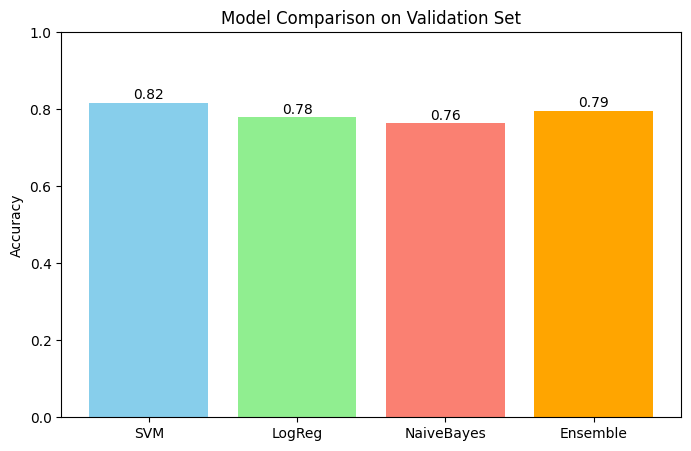

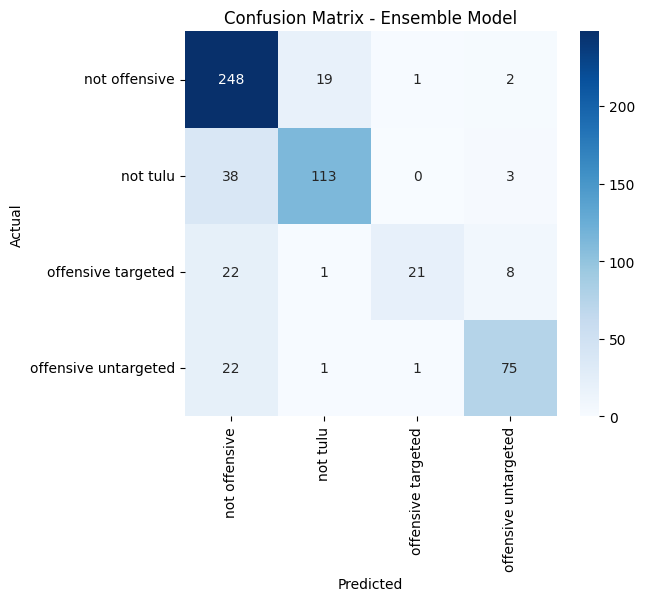

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# ✅ Step 10A: Compare individual models
models = {
    "SVM": svm_model,
    "LogReg": lr_model,
    "NaiveBayes": nb_model,
    "Ensemble": ensemble_model
}

accuracies = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_dev)
    acc = accuracy_score(y_dev, preds)
    accuracies[name] = acc

# ✅ Step 10B: Plot bar graph of accuracies
plt.figure(figsize=(8,5))
plt.bar(accuracies.keys(), accuracies.values(), color=["skyblue","lightgreen","salmon","orange"])
plt.ylabel("Accuracy")
plt.title("Model Comparison on Validation Set")
for i, v in enumerate(accuracies.values()):
    plt.text(i, v + 0.01, f"{v:.2f}", ha='center')
plt.ylim(0,1)
plt.show()

# ✅ Step 10C: Confusion Matrix for Ensemble
y_pred = ensemble_model.predict(X_dev)
cm = confusion_matrix(y_dev, y_pred, labels=np.unique(y_dev))

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Ensemble Model")
plt.show()
